If you are a CW-expert, you can explore:

1) Discovery : https://github.com/nanograv/discovery/blob/main/examples/cw_example.ipynb

2) QuickCW at : https://github.com/nanograv/quickcw

3) Prometheus paper : https://inspirehep.net/literature/2861170

# THE IPTA 2026 CW HUNT STARTS HERE!

In [2]:
import os,glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const

# enterprise
import enterprise
from enterprise.pulsar import Pulsar
from enterprise.signals import parameter, white_signals, gp_signals, signal_base, utils

# enterprise extensions
from enterprise_extensions import models, model_utils
from enterprise_extensions.frequentist import optimal_statistic as OS
from enterprise_extensions.deterministic import cw_block_circ
from enterprise_extensions.sampler import setup_sampler

# sampler
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc

#plotting
import corner

#diagnostics
import la_forge.core as co
import la_forge.diagnostics as dg

/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html


# Assemble hunters

Each pulsar is described by two files:
- **.par** — the parameter file: sky position, spin period, dispersion measure, and everything needed to predict pulse arrival times.
- **.tim** — the timing file: the actual measured pulse arrival times (TOAs).


In [3]:
DATA_DIR = './hunters/'
par_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.par')))
tim_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.tim')))

#### Make Enterprise Pulsar objects

In [4]:
psrs = []
for par, tim in zip(par_files, tim_files):
    print(f"Loading {par} and {tim}...")
    psr = Pulsar(par, tim)
    psrs.append(psr)

2026-06-16 07:54:32.281 | DEBUG    | pint.toa:get_TOAs:195 - Using EPHEM = DE440 from the given model
2026-06-16 07:54:32.281 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-06-16 07:54:32.307 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-06-16 07:54:32.311 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-06-16 07:54:32.311 | DEBUG    | pint.observatory:_load_gps_clock:108 - Loading global GPS clock file
2026-06-16 07:54:32.333 | INFO     | pint.observatory.global_clock_corrections:get_file:129 - File index.txt to be downloaded due to download policy if_expired: https://raw.githubusercontent.com/ipta/pulsar-clock-corrections/main/index.txt


Loading ./hunters/JPSR00.par and ./hunters/JPSR00.tim...


2026-06-16 07:54:37.146 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file gps2utc.clk saving kwargs={'bogus_last_correction': False, 'valid_beyond_ends': False}
2026-06-16 07:54:37.197 | DEBUG    | pint.observatory.clock_file:read_tempo2_clock_file:463 - Loading TEMPO2-format observatory clock correction file gps2utc.clk (/Users/ashokan/.astropy/cache/download/url/d3c81b5766f4bfb84e65504c8a453085/contents) with bogus_last_correction=False
2026-06-16 07:54:37.210 | INFO     | pint.observatory:find_clock_file:973 - Using global clock file for gps2utc.clk with bogus_last_correction=False
2026-06-16 07:54:37.211 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-06-16 07:54:37.211 | INFO     | pint.observatory:_load_bipm_clock:119 - Loading BIPM clock version bipm2021
2026-06-16 07:54:37.212 | DEBUG    | pint.observatory.clock_file:__init__:812 - Global clock file tai2tt_bipm2021.clk saving kwargs={'bo

Loading ./hunters/JPSR01.par and ./hunters/JPSR01.tim...
Loading ./hunters/JPSR02.par and ./hunters/JPSR02.tim...


2026-06-16 07:54:38.002 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-16 07:54:38.003 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-16 07:54:38.011 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-06-16 07:54:38.011 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-06-16 07:54:38.013 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:38.023 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671432e+10  1.34133391e+11  5.81464894e+10] m
2026-06-16 07:54:38.023 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:38.024 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:38.024 | IN

...

Loading ./hunters/JPSR15.par and ./hunters/JPSR15.tim...
Loading ./hunters/JPSR16.par and ./hunters/JPSR16.tim...


2026-06-16 07:54:39.886 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-16 07:54:39.886 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-16 07:54:39.894 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-06-16 07:54:39.895 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-06-16 07:54:39.898 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:39.907 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671431e+10  1.34133391e+11  5.81464894e+10] m
2026-06-16 07:54:39.908 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:39.908 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:39.909 | IN

Loading ./hunters/JPSR17.par and ./hunters/JPSR17.tim...
Loading ./hunters/JPSR18.par and ./hunters/JPSR18.tim...


2026-06-16 07:54:40.156 | DEBUG    | pint.toa:compute_TDBs:2278 - Computing TDB columns.
2026-06-16 07:54:40.157 | DEBUG    | pint.toa:compute_TDBs:2299 - Using EPHEM = DE440 for TDB calculation.
2026-06-16 07:54:40.165 | DEBUG    | pint.toa:get_TOAs:310 - Planet PosVels will be calculated.
2026-06-16 07:54:40.165 | DEBUG    | pint.toa:compute_posvels:2374 - Computing PosVels of observatories, Earth and planets, using DE440
2026-06-16 07:54:40.167 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:40.176 | DEBUG    | pint.toa:compute_posvels:2432 - SSB obs pos [-1.16671432e+10  1.34133391e+11  5.81464894e+10] m
2026-06-16 07:54:40.177 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:40.177 | INFO     | pint.solar_system_ephemerides:load_kernel:194 - Set solar system ephemeris to de440 through astropy
2026-06-16 07:54:40.177 | IN

Loading ./hunters/JPSR19.par and ./hunters/JPSR19.tim...


# Understand the data

How many pulsars do we have? 

In [75]:
len(psrs)

20

What are their names?

In [76]:
print("Pulsar names:")
for psr in psrs:
    print(psr.name)

Pulsar names:
JPSR00
JPSR01
JPSR02
JPSR03
JPSR04
JPSR05
JPSR06
JPSR07
JPSR08
JPSR09
JPSR10
JPSR11
JPSR12
JPSR13
JPSR14
JPSR15
JPSR16
JPSR17
JPSR18
JPSR19


How many TOAs do each pulsar have? 

In [77]:
for psr in psrs:
    print(len(psr.toas))

147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147
147


What is the time span of the data for each pulsar?

In [78]:
for psr in psrs:
    end_toa = psr.toas.max()
    start_toa = psr.toas.min()
    timespan_years = (end_toa - start_toa)/(86400*365.25)
    print("Pulsar ",psr.name, " has a timespan of ", timespan_years, " years of data.")

Pulsar  JPSR00  has a timespan of  11.991786387164314  years of data.
Pulsar  JPSR01  has a timespan of  11.99178729202828  years of data.
Pulsar  JPSR02  has a timespan of  11.99178664988047  years of data.
Pulsar  JPSR03  has a timespan of  11.99178733920596  years of data.
Pulsar  JPSR04  has a timespan of  11.991786742696146  years of data.
Pulsar  JPSR05  has a timespan of  11.991787142014326  years of data.
Pulsar  JPSR06  has a timespan of  11.991785764288629  years of data.
Pulsar  JPSR07  has a timespan of  11.99178573576619  years of data.
Pulsar  JPSR08  has a timespan of  11.991785940050242  years of data.
Pulsar  JPSR09  has a timespan of  11.991785780323271  years of data.
Pulsar  JPSR10  has a timespan of  11.991786491849181  years of data.
Pulsar  JPSR11  has a timespan of  11.991786948521243  years of data.
Pulsar  JPSR12  has a timespan of  11.991786741615718  years of data.
Pulsar  JPSR13  has a timespan of  11.991786649727405  years of data.
Pulsar  JPSR14  has a ti

### Homework : Where are the pulsars located on the sky?

# Set up PTA!

You have already learnt that Pulsars have intrinsic red noise, noise contributions from ISM, the data also has white noise from various telescope/observation effects. 

In this tutorial, we will only have white noise in the data for simplicity. And so that, this tutorial can actually be completed today.

In [10]:
# timing model
tm = gp_signals.TimingModel()

#Noise can be pre-estimated from the single-pulsar noise analysis. Here, lets try to estimate white-noise along with the gravitational wave signal.
efac = parameter.Uniform(0.1, 5.0)

# white noise
ef = white_signals.MeasurementNoise(efac=efac)


##### We will search for circular orbit CW signals. So we will use the `cw_block_circ` function from enterprise_extensions to create a signal model.

We will do an all-sky broad-frequency search for the Earth-term of the CW.

In [11]:
cw = cw_block_circ(amp_prior='log-uniform',#
                   skyloc=None,        # None = search full sky
                   log10_fgw=None,     # None = search over frequency
                   psrTerm=False,       # include pulsar term?
                   tref=53000*86400)   # reference time in seconds
                   


In [12]:
# full model = white noise + timing model + CW
model = ef + tm + cw

# initialize PTA
pulsar_models = []
for psr in psrs:
    print(f"Setting up model for {psr.name}...")
    model(psr)  # This initializes the model for the pulsar
    pulsar_models.append(model(psr))

pta = signal_base.PTA(pulsar_models)

Setting up model for JPSR00...
Setting up model for JPSR01...
Setting up model for JPSR02...
Setting up model for JPSR03...
Setting up model for JPSR04...
Setting up model for JPSR05...
Setting up model for JPSR06...
Setting up model for JPSR07...
Setting up model for JPSR08...
Setting up model for JPSR09...
Setting up model for JPSR10...
Setting up model for JPSR11...
Setting up model for JPSR12...
Setting up model for JPSR13...
Setting up model for JPSR14...
Setting up model for JPSR15...
Setting up model for JPSR16...
Setting up model for JPSR17...
Setting up model for JPSR18...
Setting up model for JPSR19...


## Always make sure you are happy with how your PTA looks!
pta.summary() is your friend.

In [13]:
print(pta.summary())

enterprise v3.4.4,  Python v3.10.20

Signal Name                              Signal Class                   no. Parameters      
JPSR00_measurement_noise                 MeasurementNoise               1                   

params:
JPSR00_efac:Uniform(pmin=0.1, pmax=5.0)                                                   
__________________________________________________________________________________________
JPSR00_linear_timing_model               TimingModel                    0                   

params:
__________________________________________________________________________________________
JPSR00_cw                                CWSignal                       8                   

params:
cw_costheta:Uniform(pmin=-1, pmax=1)                                                      
cw_phi:Uniform(pmin=0, pmax=6.283185307179586)                                            
cw_cosinc:Uniform(pmin=-1.0, pmax=1.0)                                                    
cw_log10_Mc:Unifor

### What are the 28 parameters we are varying?!
### What are the 160 common params?
### How might this look like if we decided to search over pulsar-terms?

In [14]:
print(f"Number of parameters: {len(pta.params)}")
for p in pta.params:
    print(f"  {p}")

Number of parameters: 28
  JPSR00_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR01_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR02_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR03_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR04_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR05_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR06_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR07_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR08_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR09_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR10_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR11_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR12_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR13_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR14_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR15_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR16_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR17_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR18_efac:Uniform(pmin=0.1, pmax=5.0)
  JPSR19_efac:Uniform(pmin=0.1, pmax=5.0)
  cw_cosinc:Uniform(pmin=-1.0, pmax=1.0)
  cw_costheta:Uniform(pmin=-1, pmax=1)
  cw_log10_Mc:Uniform(pmin=6.0, pmax=10.0)
  cw_log10_f

# Prepare to sampler!

In [15]:
#set up an initial starting point for the sampler
#make a dictionary of parameter names and random samples from their priors
xs = {}
for par in pta.params:
    xs[par.name] = par.sample()

#flatten the dictionary into a single array of parameter values
x0 = np.hstack([xs[par.name] for par in pta.params])
ndim = len(x0)


cov = np.diag(np.ones(ndim) * 0.1**2)

# Group parameters for more efficient sampling
# Group 1: all parameters together
groups = [list(range(0, ndim))]

# Group 2: global CW parameters only (last 8)
groups.append(list(range(ndim-8, ndim)))


sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov,
                 groups=groups,
                 outDir='./results/',
                 resume=True)

N = 30000  #short run
#x0 = np.hstack([p.sample() for p in pta.params])
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 0.00 percent (0.00 percent of new work) in 0.001435 s Acceptance rate = 0

/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log


Finished 33.33 percent (33.33 percent of new work) in 25.210956 s Acceptance rate = 0.445711Adding DE jump with weight 50
Finished 100.00 percent (100.00 percent of new work) in 62.125574 s Acceptance rate = 0.5265
Run Complete


# Plot posteriors of CW parameters!

CW parameters and their indices:
  [20] cw_cosinc
  [21] cw_costheta
  [22] cw_log10_Mc
  [23] cw_log10_fgw
  [24] cw_log10_h
  [25] cw_phase0
  [26] cw_phi
  [27] cw_psi


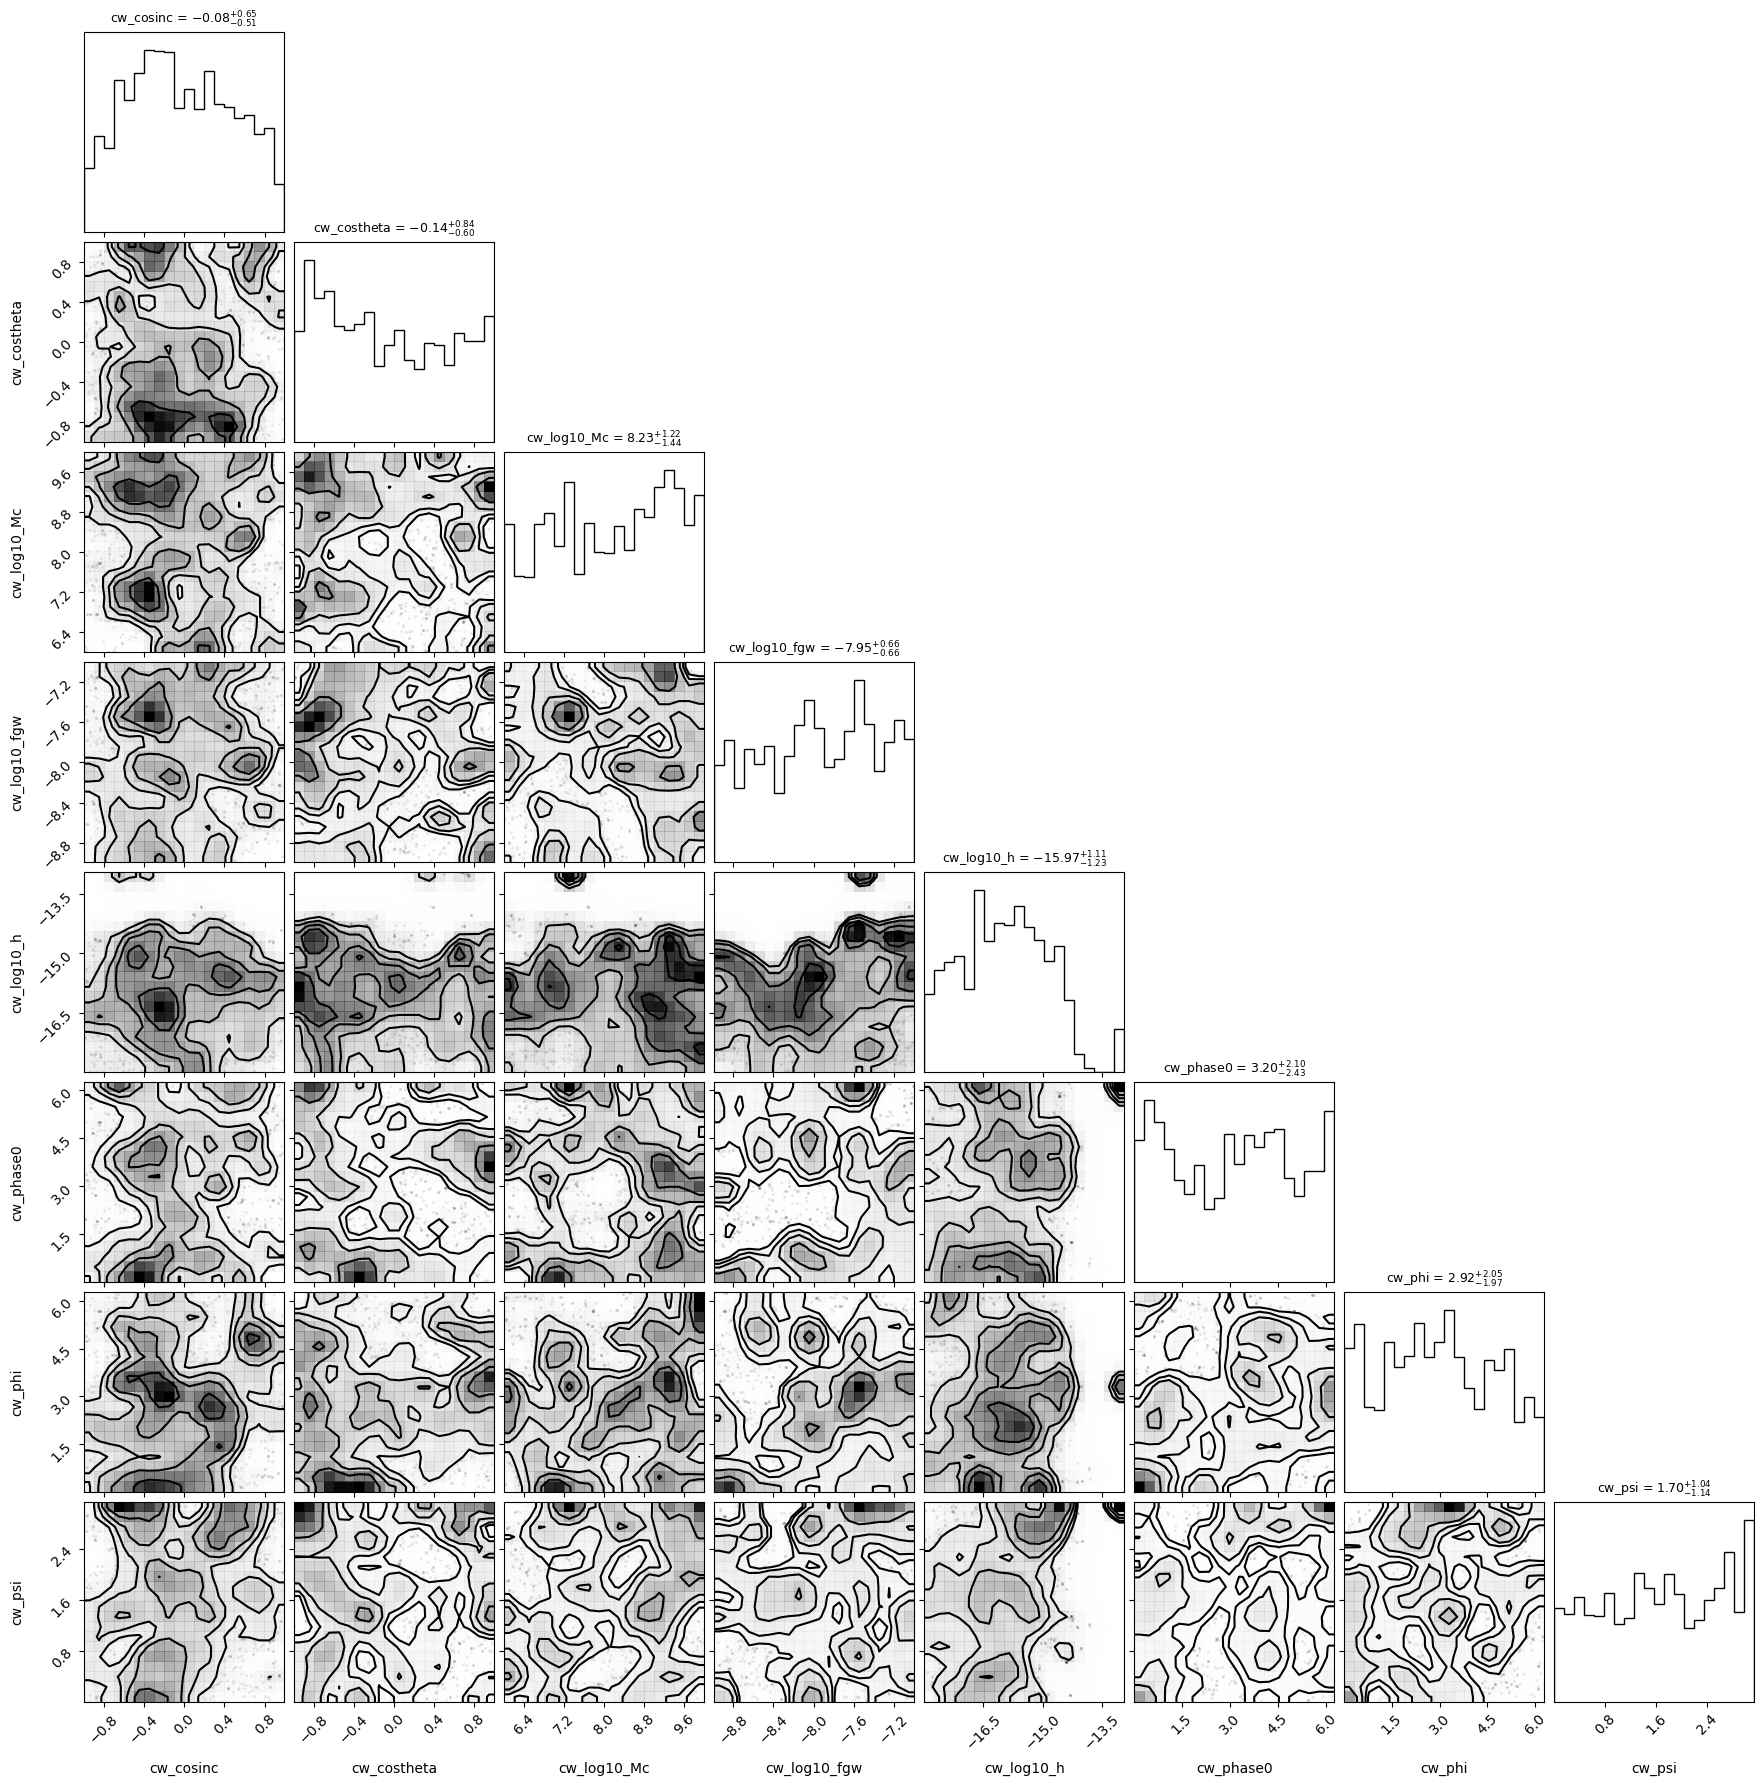

In [16]:
chain = np.loadtxt('./results/chain_1.txt')
pars = sorted(xs.keys())

# Find indices of global CW parameters (not per-pulsar)
cw_par_names = [p for p in pars if p.startswith('cw_')]
cw_par_idx = [pars.index(p) for p in cw_par_names]

print("CW parameters and their indices:")
for name, idx in zip(cw_par_names, cw_par_idx):
    print(f"  [{idx}] {name}")

# Plot corner
burn = int(0.25 * chain.shape[0])
cw_samples = chain[burn:, cw_par_idx]

fig = corner.corner(cw_samples,
                    labels=cw_par_names,
                    smooth=True,
                    show_titles=True,
                    title_kwargs={'fontsize': 9})
plt.show()


Okay. 
# Time to Diagnose the search.
We will use la-forge for this.



In [ ]:
#import la_forge.core as co
#import la_forge.diagnostics as dg
np.savetxt('./results/pars.txt', pars, fmt='%s')
chaindir = './results/'
c0 = co.Core(chaindir, burn=0.25, label='cw_hunt')
print('Number of parameters: \t',len(c0.params))
print('Chain shape: \t\t',c0.chain.shape)
print('Burn: \t\t\t' , c0.burn)

Number of parameters: 	 32
Chain shape: 		 (3001, 32)
Burn: 			 750


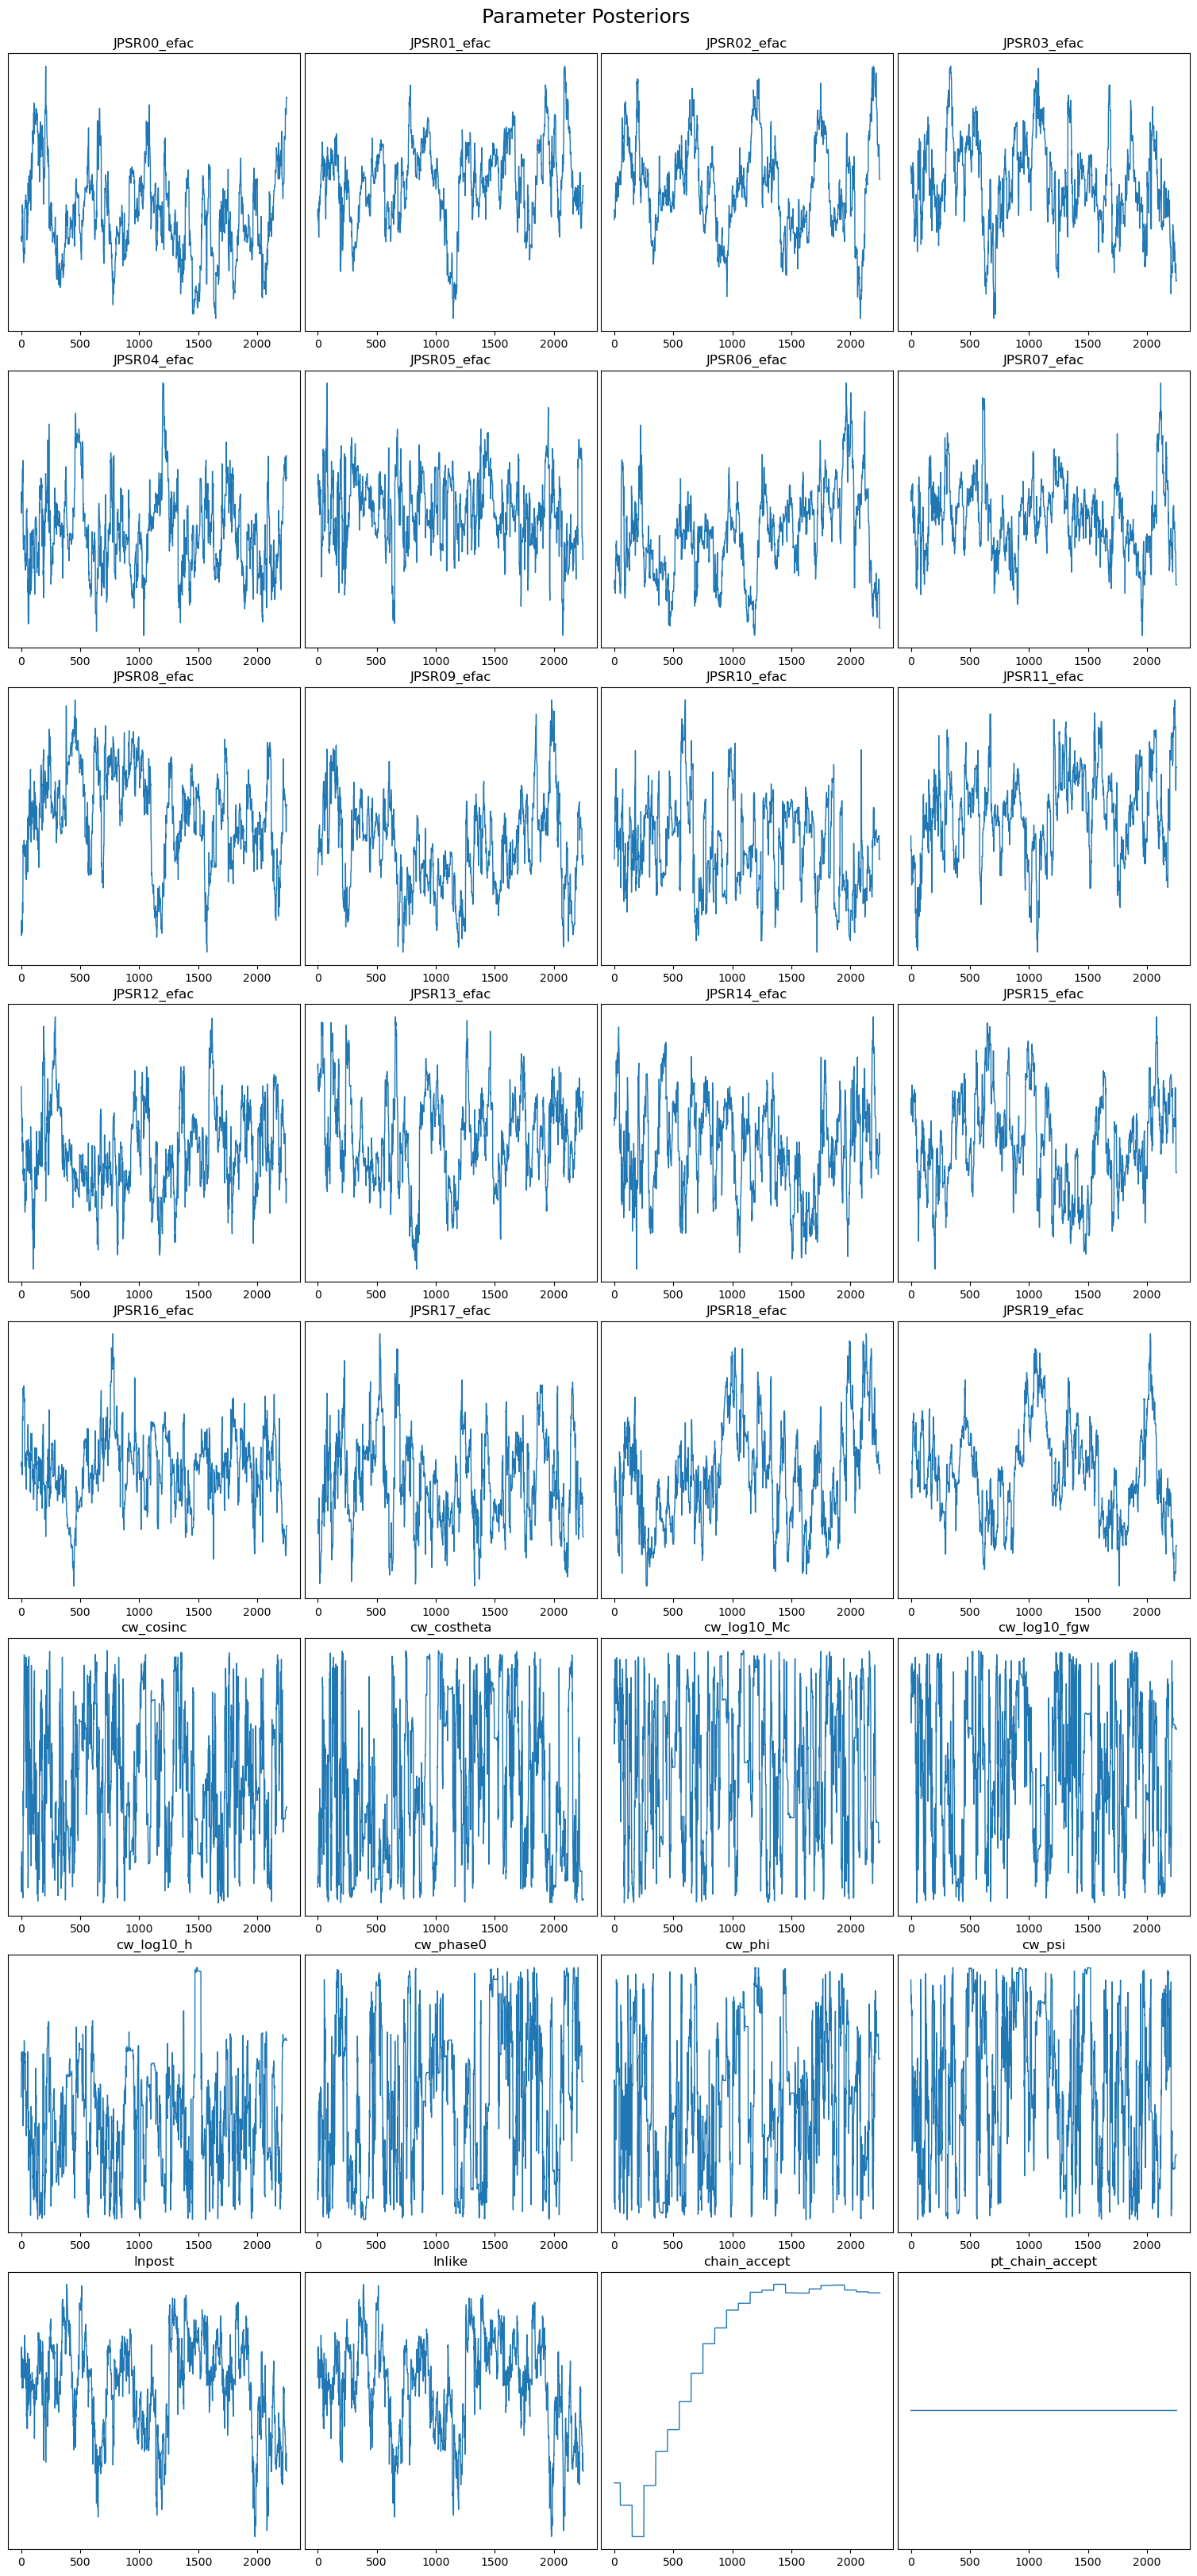

In [18]:
#check trace pltos
dg.plot_chains(c0,
               hist=False,
               pars=c0.params[:],
               ncols=4)

# What do you think?

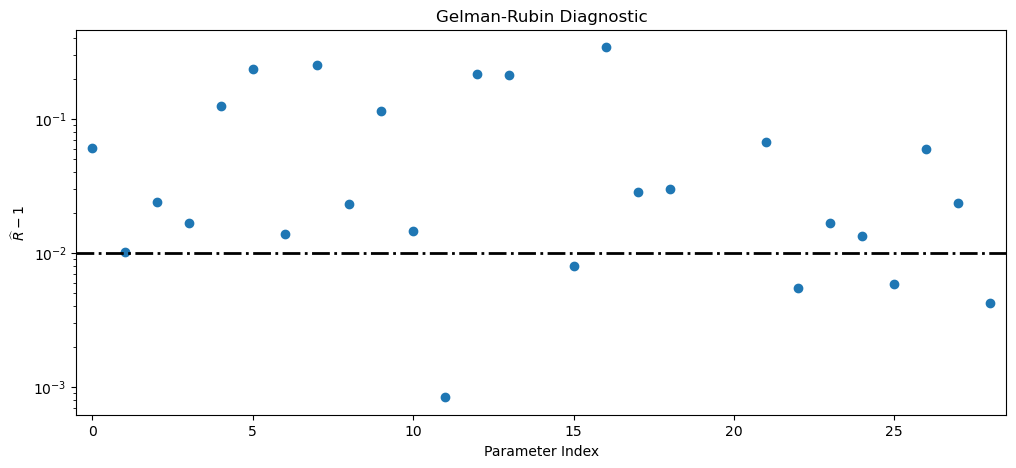

In [20]:
# Look at the Gelman Rubin diagnostic
dg.plot_grubin(c0)

# Run longer! 
Use N = 5_000_000

Remember to set Resume=True

Do the sampling later when you have time, and let it run.

Check diagnostics and CW posteriors.

In [ ]:
# sampler = ptmcmc(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov,
#                  groups=groups,
#                  outDir='./results/',
#                  resume=True)

# N = 5000000  # 3M samples
# x0 = np.hstack([p.sample() for p in pta.params])
# sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Resuming run from chain file ./results/cw_hunt_nopsrterm_9p5//chain_1.txt
Resuming with 386201 samples from file representing 3862001 original samples
Adding DE jump with weight 50


/opt/homebrew/Caskroom/mambaforge/base/envs/cw_hunt/lib/python3.10/site-packages/enterprise/signals/parameter.py:70: RuntimeWarning: divide by zero encountered in log


Finished 100.00 percent (100.00 percent of new work) in 3368.140394 s Acceptance rate = 0.154316
Run Complete


### In the interest of time, load this pre-done search.
chain = './results/cw_hunt_predone/'

Perform diagnostics.
Plot posteriors.

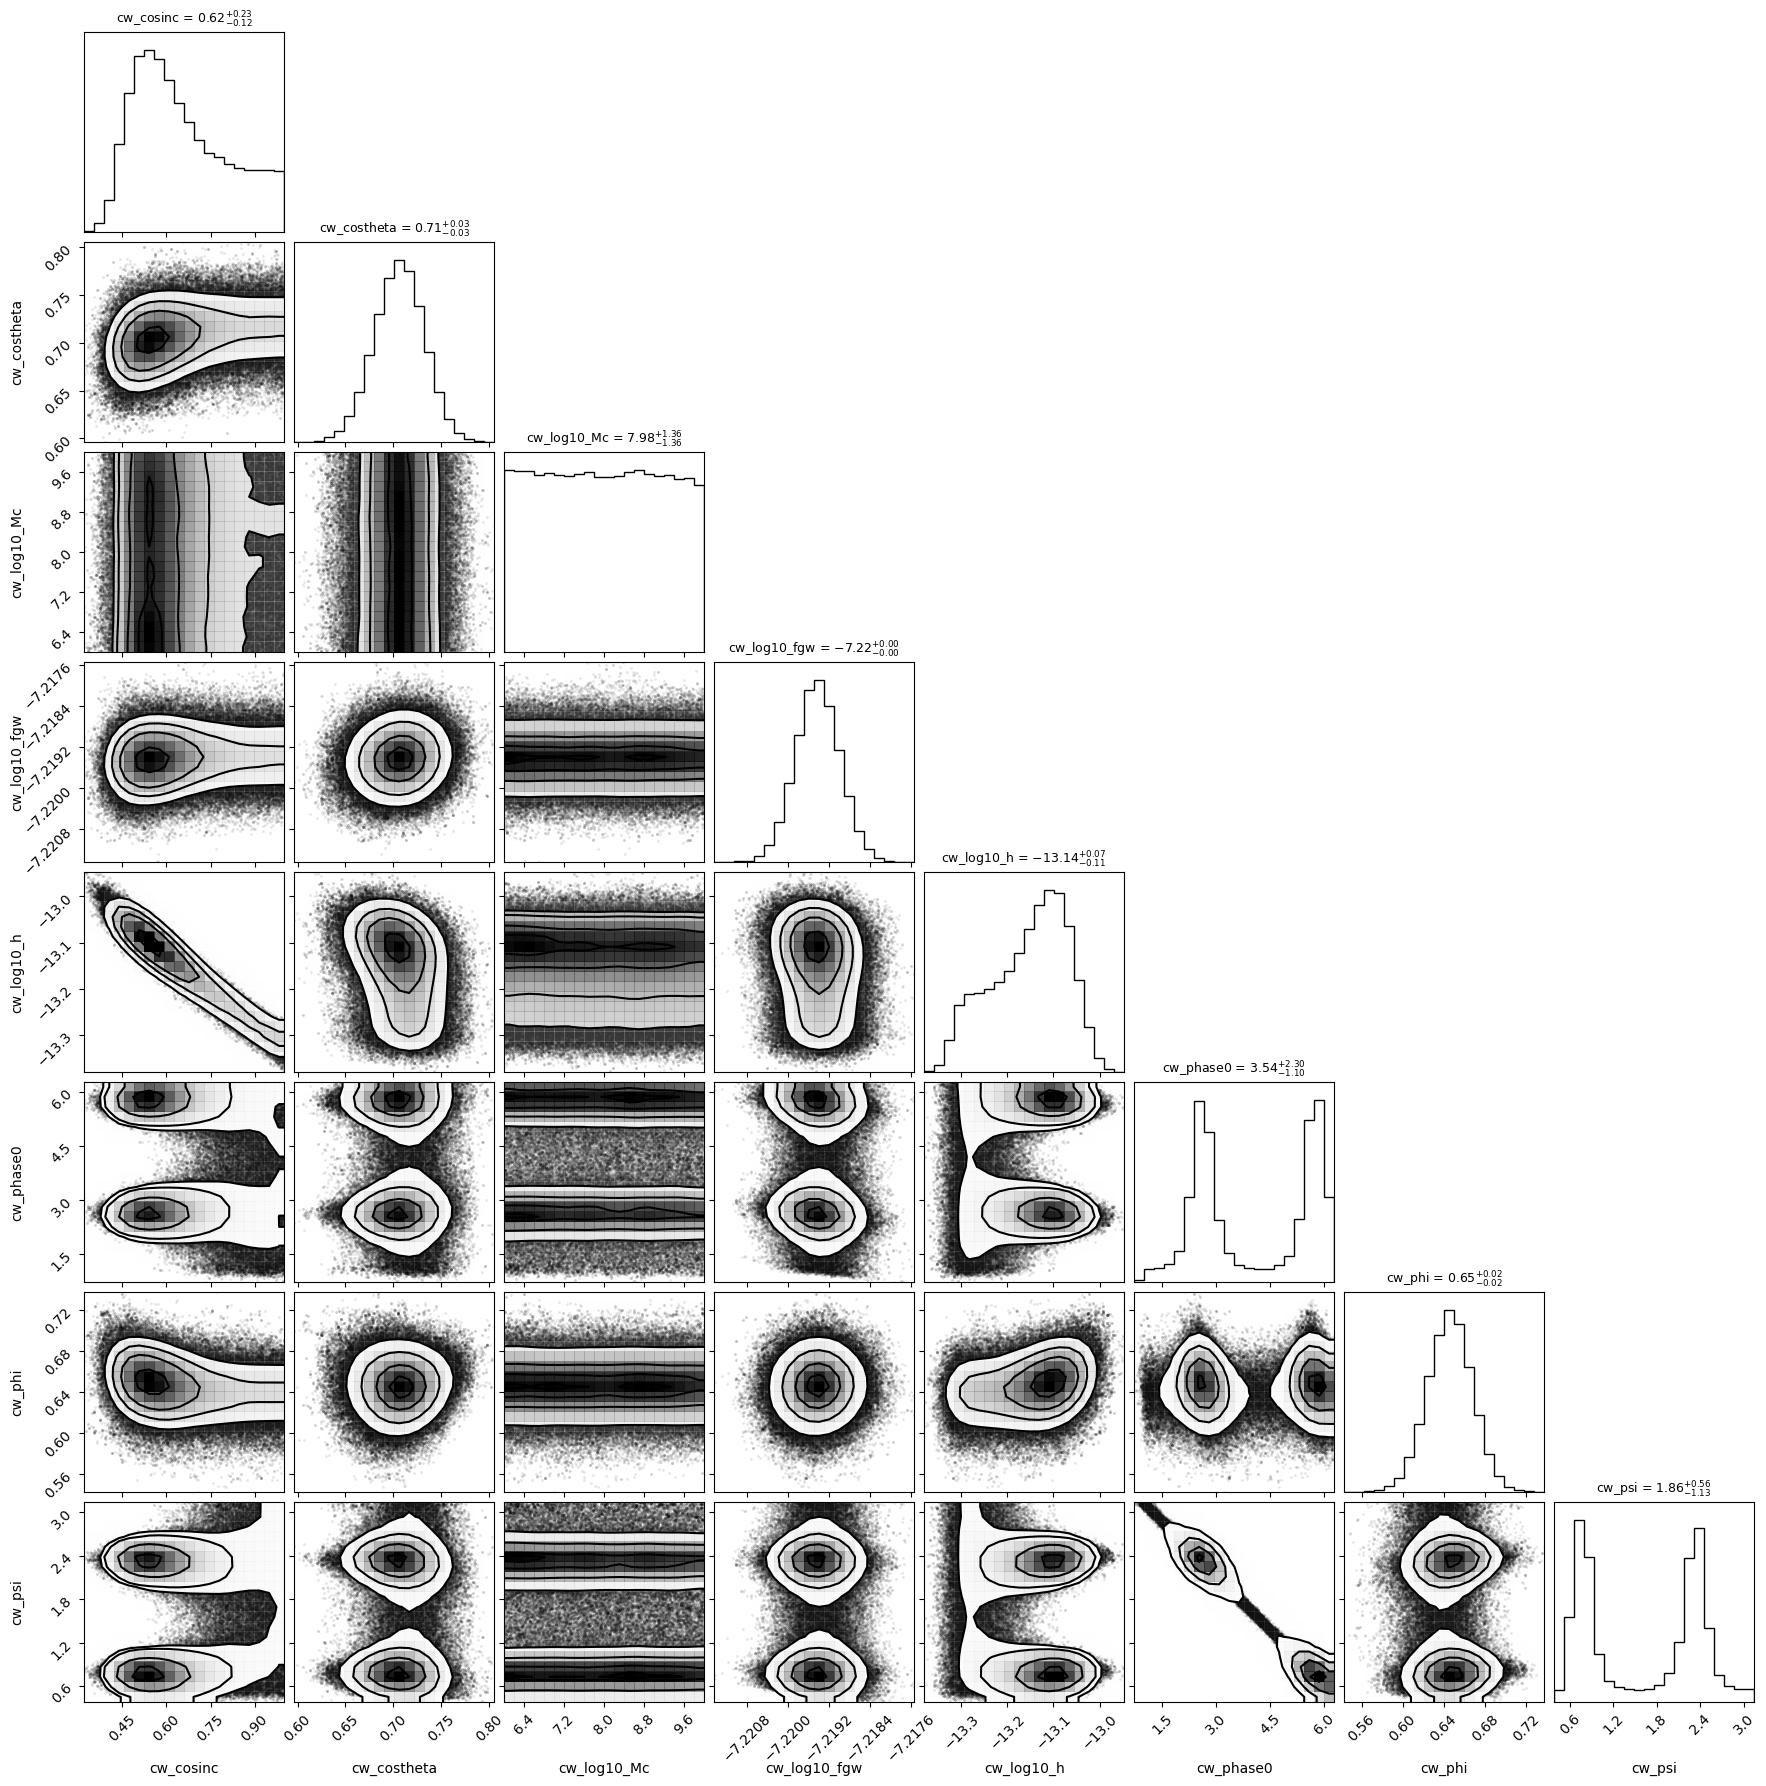

In [22]:
chain = np.loadtxt('./cw_search_predone/chain_1.txt')
pars = sorted(xs.keys())

cw_par_names = [p for p in pars if p.startswith('cw_')]# and 'p_dist' not in p and 'p_phase' not in p]
cw_par_idx = [pars.index(p) for p in cw_par_names]

# Plot corner
burn = int(0.5 * chain.shape[0])
cw_samples = chain[burn:, cw_par_idx]

fig = corner.corner(cw_samples,
                    #bins=40,
                    labels=cw_par_names,
                    smooth=True,
                    show_titles=True,
                    title_kwargs={'fontsize': 9})
plt.show()


What did we just find?